In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss

train = pd.read_csv("../../Data/train.csv")
test  = pd.read_csv("../../Data/test.csv")

train.columns = ["timestamp", "value", "label", "kpi"]
test.columns  = ["timestamp", "value", "kpi"]

train["dt"] = pd.to_datetime(train["timestamp"], unit="s")
test["dt"]  = pd.to_datetime(test["timestamp"], unit="s")
train.head()

,timestamp,value,label,kpi,dt
0,1493568000,1.901639,0,02e99bd4f6cfb33f,2017-04-30 16:00:00
1,1493568060,1.786885,0,02e99bd4f6cfb33f,2017-04-30 16:01:00
2,1493568120,2.000000,0,02e99bd4f6cfb33f,2017-04-30 16:02:00
3,1493568180,1.885246,0,02e99bd4f6cfb33f,2017-04-30 16:03:00
4,1493568240,1.819672,0,02e99bd4f6cfb33f,2017-04-30 16:04:00


In [2]:
print("TRAIN:", train.shape, "| TEST:", test.shape)
print("KPI - train:", train.kpi.nunique(), "| test:", test.kpi.nunique())
print("KPI train==test:", set(train.kpi.unique()) == set(test.kpi.unique()))
print("train timestamp:", train.dt.min(), "->", train.dt.max())
print("test  timestamp:", test.dt.min(),  "->", test.dt.max())
print("\nNaN value train:", train.value.isna().sum(), "| test:", test.value.isna().sum())
print("Anomaly rate train: %.4f%%" % (100 * train.label.mean()))
display(train.value.describe())
print("Label distribution:\n", train.label.value_counts())

TRAIN: (2476315, 5) | TEST: (2345211, 4)
KPI - train: 26 | test: 26
KPI train==test: True
train timestamp: 2016-06-30 16:00:00 -> 2017-08-11 10:20:00
test  timestamp: 2016-08-12 08:35:00 -> 2017-10-30 17:09:00

NaN value train: 0 | test: 0
Anomaly rate train: 2.1605%


count    2.476315e+06
mean     1.080211e+08
std      3.196926e+08
min     -4.546069e+00
25%      3.700000e+00
50%      1.293438e+03
75%      2.523000e+03
max      1.608813e+09
Name: value, dtype: float64

Label distribution:
 label
0    2422815
1      53500
Name: count, dtype: int64


In [3]:
rows = []

for kpi, g in train.groupby("kpi"):
    g = g.sort_values("timestamp")
    ts = g.timestamp.values
    diffs = np.diff(ts)
    step = int(pd.Series(diffs).mode().iloc[0])      # sampling interval phổ biến
    
    n = len(g)
    expected = (ts[-1] - ts[0]) // step + 1           # số điểm kỳ vọng nếu liên tục
    dup = int((diffs == 0).sum())                     # timestamp trùng
    gap_mask = diffs > step
    n_gaps = int(gap_mask.sum())
    miss_pts = int(((diffs[gap_mask] // step) - 1).sum()) if n_gaps else 0
    rows.append(dict(
        kpi=kpi[:8], n=n, step_s=step,
        coverage=round(100 * n / expected, 1),
        dup=dup, n_gaps=n_gaps, miss_pts=miss_pts,
        max_gap_min=round(diffs.max() / 60, 1),
        anom_rate=round(100 * g.label.mean(), 2),
        vmin=round(g.value.min(), 2), vmax=round(g.value.max(), 2),
    ))
summary = pd.DataFrame(rows).sort_values("n", ascending=False)
print("Phân bố sampling interval:\n", summary.step_s.value_counts())
summary

Phân bố sampling interval:
 step_s
60     19
300     7
Name: count, dtype: int64


,kpi,n,step_s,coverage,dup,n_gaps,miss_pts,max_gap_min,anom_rate,vmin,vmax
11,7c189dd3,147689,60,97.8,0,2931,3371,313.0,0.29,0.000000e+00,4.087000e+03
20,affb01ca,147680,60,97.8,0,2930,3361,313.0,0.40,0.000000e+00,4.712000e+03
8,71595dd7,147668,60,97.7,0,2938,3401,313.0,0.75,0.000000e+00,4.111000e+03
23,cff6d3c0,147629,60,97.7,0,2943,3482,313.0,0.74,0.000000e+00,4.819000e+03
25,e0770391,147024,60,96.9,0,2926,4727,1333.0,2.09,0.000000e+00,1.801800e+04
15,8c892e55,147009,60,96.9,0,2930,4756,1334.0,2.10,0.000000e+00,1.817600e+04
18,a40b1df8,137925,60,97.9,0,2464,2887,313.0,0.28,0.000000e+00,4.290000e+03
14,8bef9af9,129453,60,98.1,0,2147,2547,313.0,0.41,0.000000e+00,5.097000e+03
4,18fbb1d5,129128,60,98.0,0,43,2667,1722.0,6.09,0.000000e+00,5.104500e+02
24,da403e4e,129035,60,97.9,0,40,2755,1775.0,5.94,0.000000e+00,1.925000e+01


Tổng số anomaly segment: 933


count     933.000000
mean       57.341908
std       380.839870
min         1.000000
25%         4.000000
50%         5.000000
75%        12.000000
max      6643.000000
dtype: float64

Phân bố độ dài segment:
 =1        13
2         22
3-5      478
6-10     164
11-30    109
31-60     33
>60      114
Name: count, dtype: int64

%% segment dài =1 (point): 1.4%
%% điểm anomaly trong segment dài >1 (collective): 100.0%


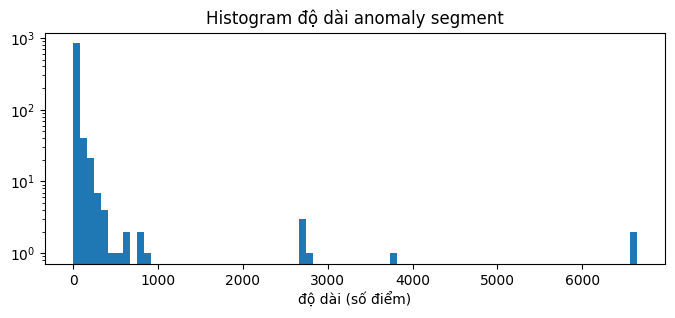

In [4]:
seg_lens, per_kpi = [], []
for kpi, g in train.groupby("kpi"):
    lab = g.sort_values("timestamp").label.values
    grp = (lab != np.r_[lab[0] - 1, lab[:-1]]).cumsum()    # nhóm các đoạn cùng giá trị
    s = pd.Series(lab).groupby(grp).agg(["first", "size"])
    anom = s[s["first"] == 1]["size"]
    seg_lens.extend(anom.tolist())
    if len(anom):
        per_kpi.append((kpi[:8], len(anom), int(anom.max()), round(anom.mean(), 1)))

seg = pd.Series(seg_lens)
print("Tổng số anomaly segment:", len(seg))
display(seg.describe())
bins   = [0, 1, 2, 5, 10, 30, 60, 1e9]
labels = ["=1", "2", "3-5", "6-10", "11-30", "31-60", ">60"]
print("Phân bố độ dài segment:\n",
      pd.cut(seg, bins=bins, labels=labels).value_counts().sort_index())
print("\n%% segment dài =1 (point):", f"{100*(seg==1).mean():.1f}%")
print("%% điểm anomaly trong segment dài >1 (collective):",
      f"{100*seg[seg>1].sum()/seg.sum():.1f}%")

plt.figure(figsize=(8, 3))
plt.hist(seg, bins=80); plt.yscale("log")
plt.title("Histogram độ dài anomaly segment"); plt.xlabel("độ dài (số điểm)"); plt.show()

In [5]:
full = {k[:8]: k for k in train.kpi.unique()}      # map prefix -> tên KPI đầy đủ
reps = {                                            # 5 KPI đại diện các nhóm hành vi
    "02e99bd4": "anomaly cao + collective mạnh",
    "09513ae3": "scale thô cực lớn ~1.6e9",
    "a5bf5d65": "anomaly cực thấp, đã chuẩn hoá",
    "da403e4e": "collective rất dài (max 6643)",
    "046ec29d": "sampling 5 phút, đủ 100%",
}

def fft_period_min(x, step_s):
    x = x - x.mean()
    sp = np.abs(np.fft.rfft(x)); sp[0] = 0
    fr = np.fft.rfftfreq(len(x), d=step_s)
    k = int(np.argmax(sp))
    return None if fr[k] == 0 else round(1 / fr[k] / 60, 1)   # chu kỳ (phút)

for pre, desc in reps.items():
    g = train[train.kpi == full[pre]].sort_values("timestamp")
    x = g.value.values.astype(float)
    step = int(pd.Series(np.diff(g.timestamp.values)).mode().iloc[0])
    xs = x[:50000]                                   # sample cho ADF chạy nhanh
    adf_p = adfuller(xs, autolag="AIC")[1]
    try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]
    except: kp_p = np.nan
    per = fft_period_min(x, step)
    concl = ("stationary" if adf_p < 0.05 and kp_p >= 0.05 else
             "non-stationary" if adf_p >= 0.05 and kp_p < 0.05 else
             "mâu thuẫn -> deterministic trend?" if adf_p < 0.05 and kp_p < 0.05 else
             "không đủ KL")
    print(f"{pre} | {desc}")
    print(f"   ADF p={adf_p:.3g} | KPSS p={kp_p:.3g} -> {concl} | "
          f"FFT chu kỳ chủ đạo ~ {per} phút\n")

C:\Users\admin\AppData\Local\Temp\ipykernel_38868\2981754438.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]


02e99bd4 | anomaly cao + collective mạnh
   ADF p=7.62e-09 | KPSS p=0.1 -> stationary | FFT chu kỳ chủ đạo ~ 1444.5 phút



C:\Users\admin\AppData\Local\Temp\ipykernel_38868\2981754438.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]


09513ae3 | scale thô cực lớn ~1.6e9
   ADF p=2.8e-13 | KPSS p=0.01 -> mâu thuẫn -> deterministic trend? | FFT chu kỳ chủ đạo ~ 6448.6 phút



C:\Users\admin\AppData\Local\Temp\ipykernel_38868\2981754438.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]


a5bf5d65 | anomaly cực thấp, đã chuẩn hoá
   ADF p=0 | KPSS p=0.1 -> stationary | FFT chu kỳ chủ đạo ~ 9898.4 phút



C:\Users\admin\AppData\Local\Temp\ipykernel_38868\2981754438.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]


da403e4e | collective rất dài (max 6643)
   ADF p=3.75e-07 | KPSS p=0.01 -> mâu thuẫn -> deterministic trend? | FFT chu kỳ chủ đạo ~ 1449.8 phút

046ec29d | sampling 5 phút, đủ 100%
   ADF p=8.77e-23 | KPSS p=0.01 -> mâu thuẫn -> deterministic trend? | FFT chu kỳ chủ đạo ~ 1464.0 phút



C:\Users\admin\AppData\Local\Temp\ipykernel_38868\2981754438.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try:    kp_p = kpss(xs, regression="c", nlags="auto")[1]


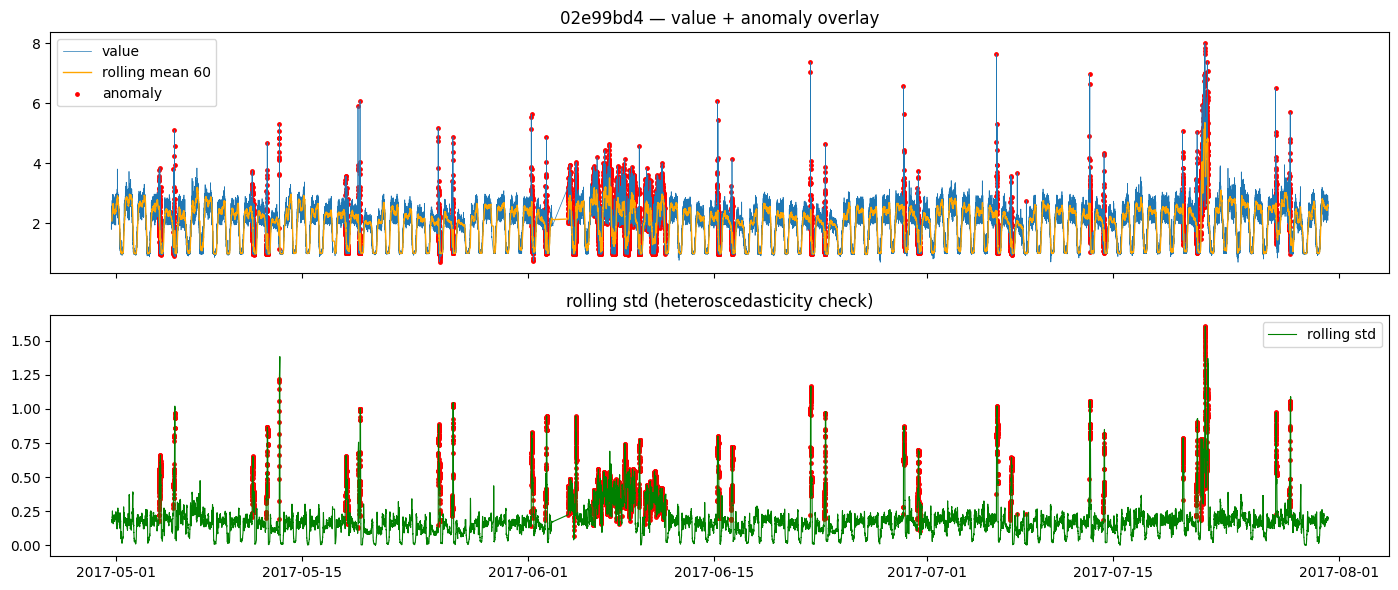

In [8]:
pre = "02e99bd4"                                     # đổi KPI tùy ý
g = train[train.kpi == full[pre]].sort_values("dt").set_index("dt")
w = 60                                               # window ~1h (1-min sampling)

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax[0].plot(g.index, g.value, lw=0.5, label="value")
ax[0].plot(g.index, g.value.rolling(w).mean(), color="orange", lw=1, label=f"rolling mean {w}")
ax[0].scatter(g.index[g.label == 1], g.value[g.label == 1], color="red", s=6, label="anomaly")
ax[0].legend(); ax[0].set_title(f"{pre} — value + anomaly overlay")

ax[1].plot(g.index, g.value.rolling(w).std(), color="green", lw=0.8, label="rolling std")
ax[1].scatter(g.index[g.label == 1], g.value.rolling(w).std()[g.label == 1],
              color="red", s=6)
ax[1].legend(); ax[1].set_title("rolling std (heteroscedasticity check)")
plt.tight_layout(); plt.show()

1. Cấu trúc dataset & tính hợp lệ

- 26 KPI, train/test cùng tập KPI, test bắt đầu (2016-08-12) — lưu ý: test span bao trùm cả khoảng train (2016-06-30 → 2017-08-11). Đây không phải split thời gian thuần tuý tách rời; mỗi KPI mới là một timeline riêng. ⇒ Khi đánh giá phải split theo thời gian trong từng KPI, không trộn KPI.
- 0 NaN trong value ở cả train & test, 0 timestamp trùng → data sạch ở mức record. Vấn đề thiếu nằm hoàn toàn ở gap timeline, không phải NaN.

2. Hai chế độ sampling rõ rệt → bài toán bị phân mảnh

- 19 KPI @60s (chuỗi dài ~100k–148k điểm) và 7 KPI @300s (chuỗi ngắn ~8k–11k điểm). Chênh lệch độ dài ~18 lần.
- Hệ quả: KPI 5-phút không đủ độ dài để học seasonal/STL tin cậy (chỉ vài chục–trăm chu kỳ ngày), và mọi thao tác cross-metric / window phải xử lý riêng theo nhóm tần suất.

3. Gap = downtime thu thập, không phải nhiễu lẻ

- Nhóm KPI 60s tách làm 2 kiểu gap rất khác:
  - Gap dày, ngắn: ~2900–2940 gap nhưng max_gap ≈ 313 phút (7c189dd3, affb01ca, 71595dd7…) → mất rải rác đều.
  - Gap thưa, rất dài: ~40 gap nhưng max_gap ≈ 1700–1800 phút (~30h) (09513ae3, a5bf5d65, 02e99bd4…) → vài cú downtime kéo dài.
- ⇒ Đây là 2 cơ chế lỗi hệ thống khác nhau, và bản thân gap dài có thể là collecting-failure anomaly. Imputation phải tùy theo độ dài gap (gap 30h không thể nội suy tuyến tính).

4. Scale value cực kỳ dị biệt → bắt buộc chuẩn hoá per-KPI

- value toàn cục: median ~1293 nhưng max 1.6e9, min −4.5. Ba "thế giới" khác nhau cùng tồn tại:
  - KPI thô scale lớn: 09513ae3, c58bfcba (~5e8 → 1.6e9).
  - KPI count vừa: hàng nghìn (request-rate-like).
  - KPI đã chuẩn hoá z-score sẵn: 07927a9a, 046ec29d, 54e8a140, b3b2e6d1 (min âm ~−4.5, range ~−4.5..3).
- ⇒ Không thể có ngưỡng/độ đo toàn cục. Mọi feature & detector phải normalize theo từng KPI; "value < 0" chỉ hợp lệ ở nhóm đã chuẩn hoá.

5. Anomaly: hiếm, lệch mạnh giữa KPI, và gần như thuần collective

- Rate toàn cục 2.16%, nhưng per-KPI trải từ 0.02% (a5bf5d65) → 8.21% (02e99bd4) — chênh ~400 lần. ⇒ Không dùng một ngưỡng/chiến lược chung; metric phải là F1 / PR-based, không phải accuracy.
- 933 segment, chỉ 1.4% dài =1; median độ dài 5, max 6643 điểm; ~100% điểm anomaly nằm trong segment dài >1. → Dataset là collective/subsequence anomaly, không phải point outlier.
- ⇒ Đây là insight quan trọng nhất cho modeling: detector per-point (rolling z-score, IQR) sẽ bắt được "rìa" nhưng miss thân segment dài → cần point-adjust metric (đúng cách AIOps Challenge chấm) và detector dạng window/shape/reconstruction (Isolation Forest shingle, RCF, STL-residual).

6. Stationarity & seasonality

- Seasonality ngày rất rõ: 02e99bd4, da403e4e, 046ec29d đều cho FFT đỉnh ~1440–1464 phút ≈ 24h → period = 1440 (60s) / 288 (300s) là tham số STL hợp lý.
- ADF + KPSS mâu thuẫn ở nhiều KPI (09513ae3, da403e4e, 046ec29d): ADF bác bỏ mạnh nhưng KPSS cũng bác bỏ → dấu hiệu deterministic trend, cần detrend trước khi kết luận stationary.
- Cảnh báo về FFT: 09513ae3 (6449 phút) và a5bf5d65 (9898 phút) cho chu kỳ chủ đạo dài vô lý — đỉnh FFT bị trend/broadband noise (do anomaly) lấn át, không phải seasonality thật. ⇒ Phải clip outlier + detrend rồi chạy lại FFT mới tin được period cho 2 KPI này.